In [4]:
# =============================================================================
# DAY 3 — EXPLORATORY DATA ANALYSIS (EDA)
# Project: Customer Churn Analytics & Prediction
# =============================================================================
# TASKS:
#   Task 1 — Reload dataset & fix TotalCharges dtype
#   Task 2 — Univariate analysis (distributions)
#   Task 3 — Bivariate analysis (features vs Churn)
#   Task 4 — Correlation heatmap & multicollinearity check
#   Task 5 — EDA findings summary
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import warnings

warnings.filterwarnings("ignore")

# ── Plotting style ────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi"      : 130,
    "axes.titlesize"  : 11,
    "axes.labelsize"  : 10,
    "xtick.labelsize" : 9,
    "ytick.labelsize" : 9,
    "legend.fontsize" : 9,
})

# Colour palette (consistent across all Day 3 charts)
CLR_RETAIN = "#1D9E75"   # green  — No churn
CLR_CHURN  = "#E24B4A"   # red    — Churned
CLR_NEUT   = "#378ADD"   # blue   — neutral bars

os.makedirs("../visuals", exist_ok=True)

print("=" * 60)
print("  DAY 3 — EXPLORATORY DATA ANALYSIS")
print("=" * 60)

  DAY 3 — EXPLORATORY DATA ANALYSIS


In [6]:
# =============================================================================
# TASK 1 — RELOAD DATASET & FIX TOTALCHARGES
# =============================================================================
print("\n[TASK 1] Loading dataset & fixing TotalCharges...")

DATA_PATH = "C:/Users/white/Downloads/Learn/Churn_project/data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(DATA_PATH)

# Fix TotalCharges: blank strings → NaN → float
# (11 rows have blank TotalCharges — these are new customers with tenure = 0)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].str.strip(), errors="coerce")

# For EDA purposes, fill the 11 NaNs with 0 (tenure=0 → no charges yet)
tc_nulls_before = df["TotalCharges"].isnull().sum()
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print(f"  Rows            : {df.shape[0]:,}")
print(f"  Columns         : {df.shape[1]}")
print(f"  TotalCharges NaN fixed : {tc_nulls_before} rows → filled with 0")
print(f"  Churn col dtype : {df['Churn'].dtype}  (Yes/No strings — kept as-is for EDA)")

# ── Convenience: binary churn column for correlations ────────────────────────
df["Churn_bin"] = (df["Churn"] == "Yes").astype(int)

# ── Column type buckets ───────────────────────────────────────────────────────
NUM_COLS = ["tenure", "MonthlyCharges", "TotalCharges"]
CAT_COLS = [
    "gender", "SeniorCitizen", "Partner", "Dependents",
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod"
]

print(f"\n  Numerical columns : {NUM_COLS}")
print(f"  Categorical cols  : {len(CAT_COLS)} columns")
print("\n  Task 1 complete ✓")


[TASK 1] Loading dataset & fixing TotalCharges...
  Rows            : 7,043
  Columns         : 21
  TotalCharges NaN fixed : 11 rows → filled with 0
  Churn col dtype : str  (Yes/No strings — kept as-is for EDA)

  Numerical columns : ['tenure', 'MonthlyCharges', 'TotalCharges']
  Categorical cols  : 16 columns

  Task 1 complete ✓



[TASK 2] Univariate analysis...


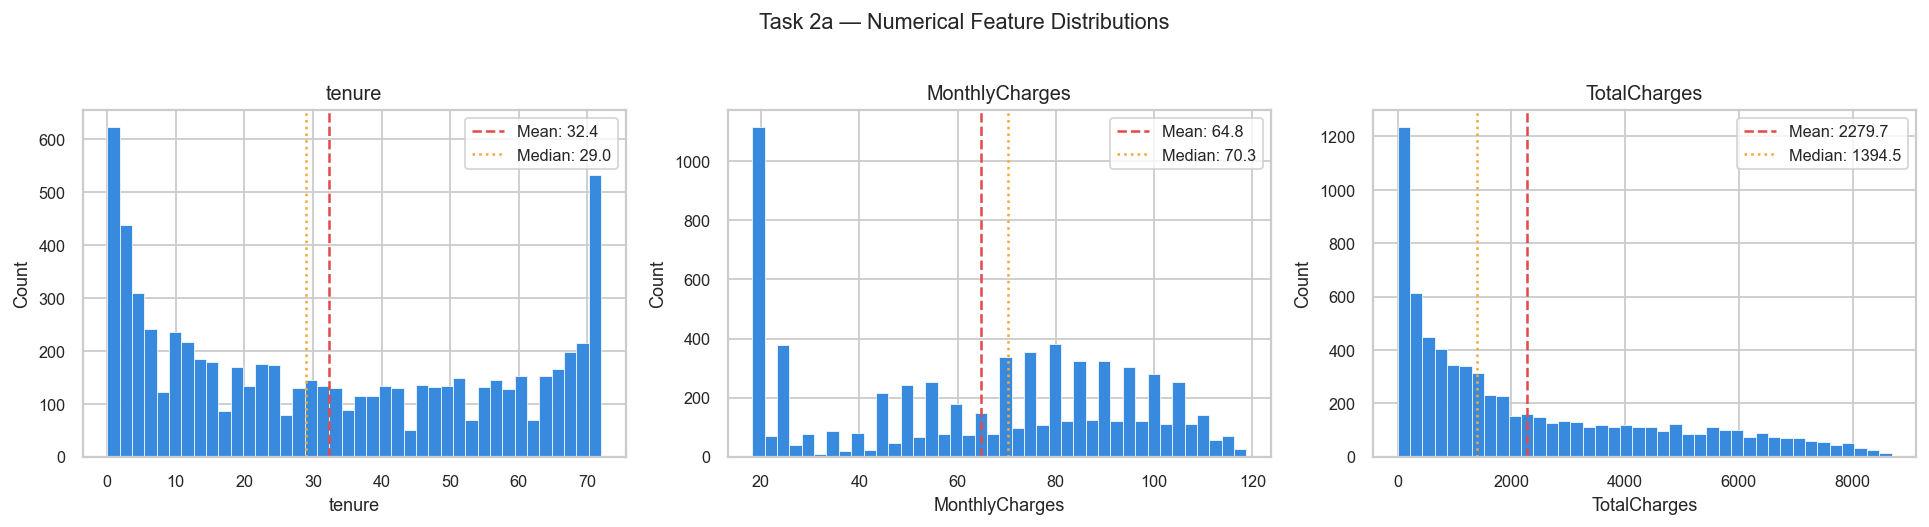

  Chart saved: day3_univariate_numerical.png

  NUMERICAL COLUMN STATISTICS
                 count         mean          std    min     25%      50%      75%      max   skew  kurtosis
tenure          7043.0    32.371149    24.559481   0.00    9.00    29.00    55.00    72.00  0.240    -1.387
MonthlyCharges  7043.0    64.761692    30.090047  18.25   35.50    70.35    89.85   118.75 -0.221    -1.257
TotalCharges    7043.0  2279.734304  2266.794470   0.00  398.55  1394.55  3786.60  8684.80  0.963    -0.229

  Interpretation:
  • tenure       — Bimodal: spikes at 0-2 months (new) and ~70 months (loyal)
  • MonthlyCharges — Right-leaning; premium tier customers visible ~$80-100
  • TotalCharges  — Right-skewed (expected: high tenure = high total spend)

  CATEGORICAL COLUMN VALUE COUNTS

  gender:
    Male                           3,555  (50.5%)
    Female                         3,488  (49.5%)

  SeniorCitizen:
    0                              5,901  (83.8%)
    1                        

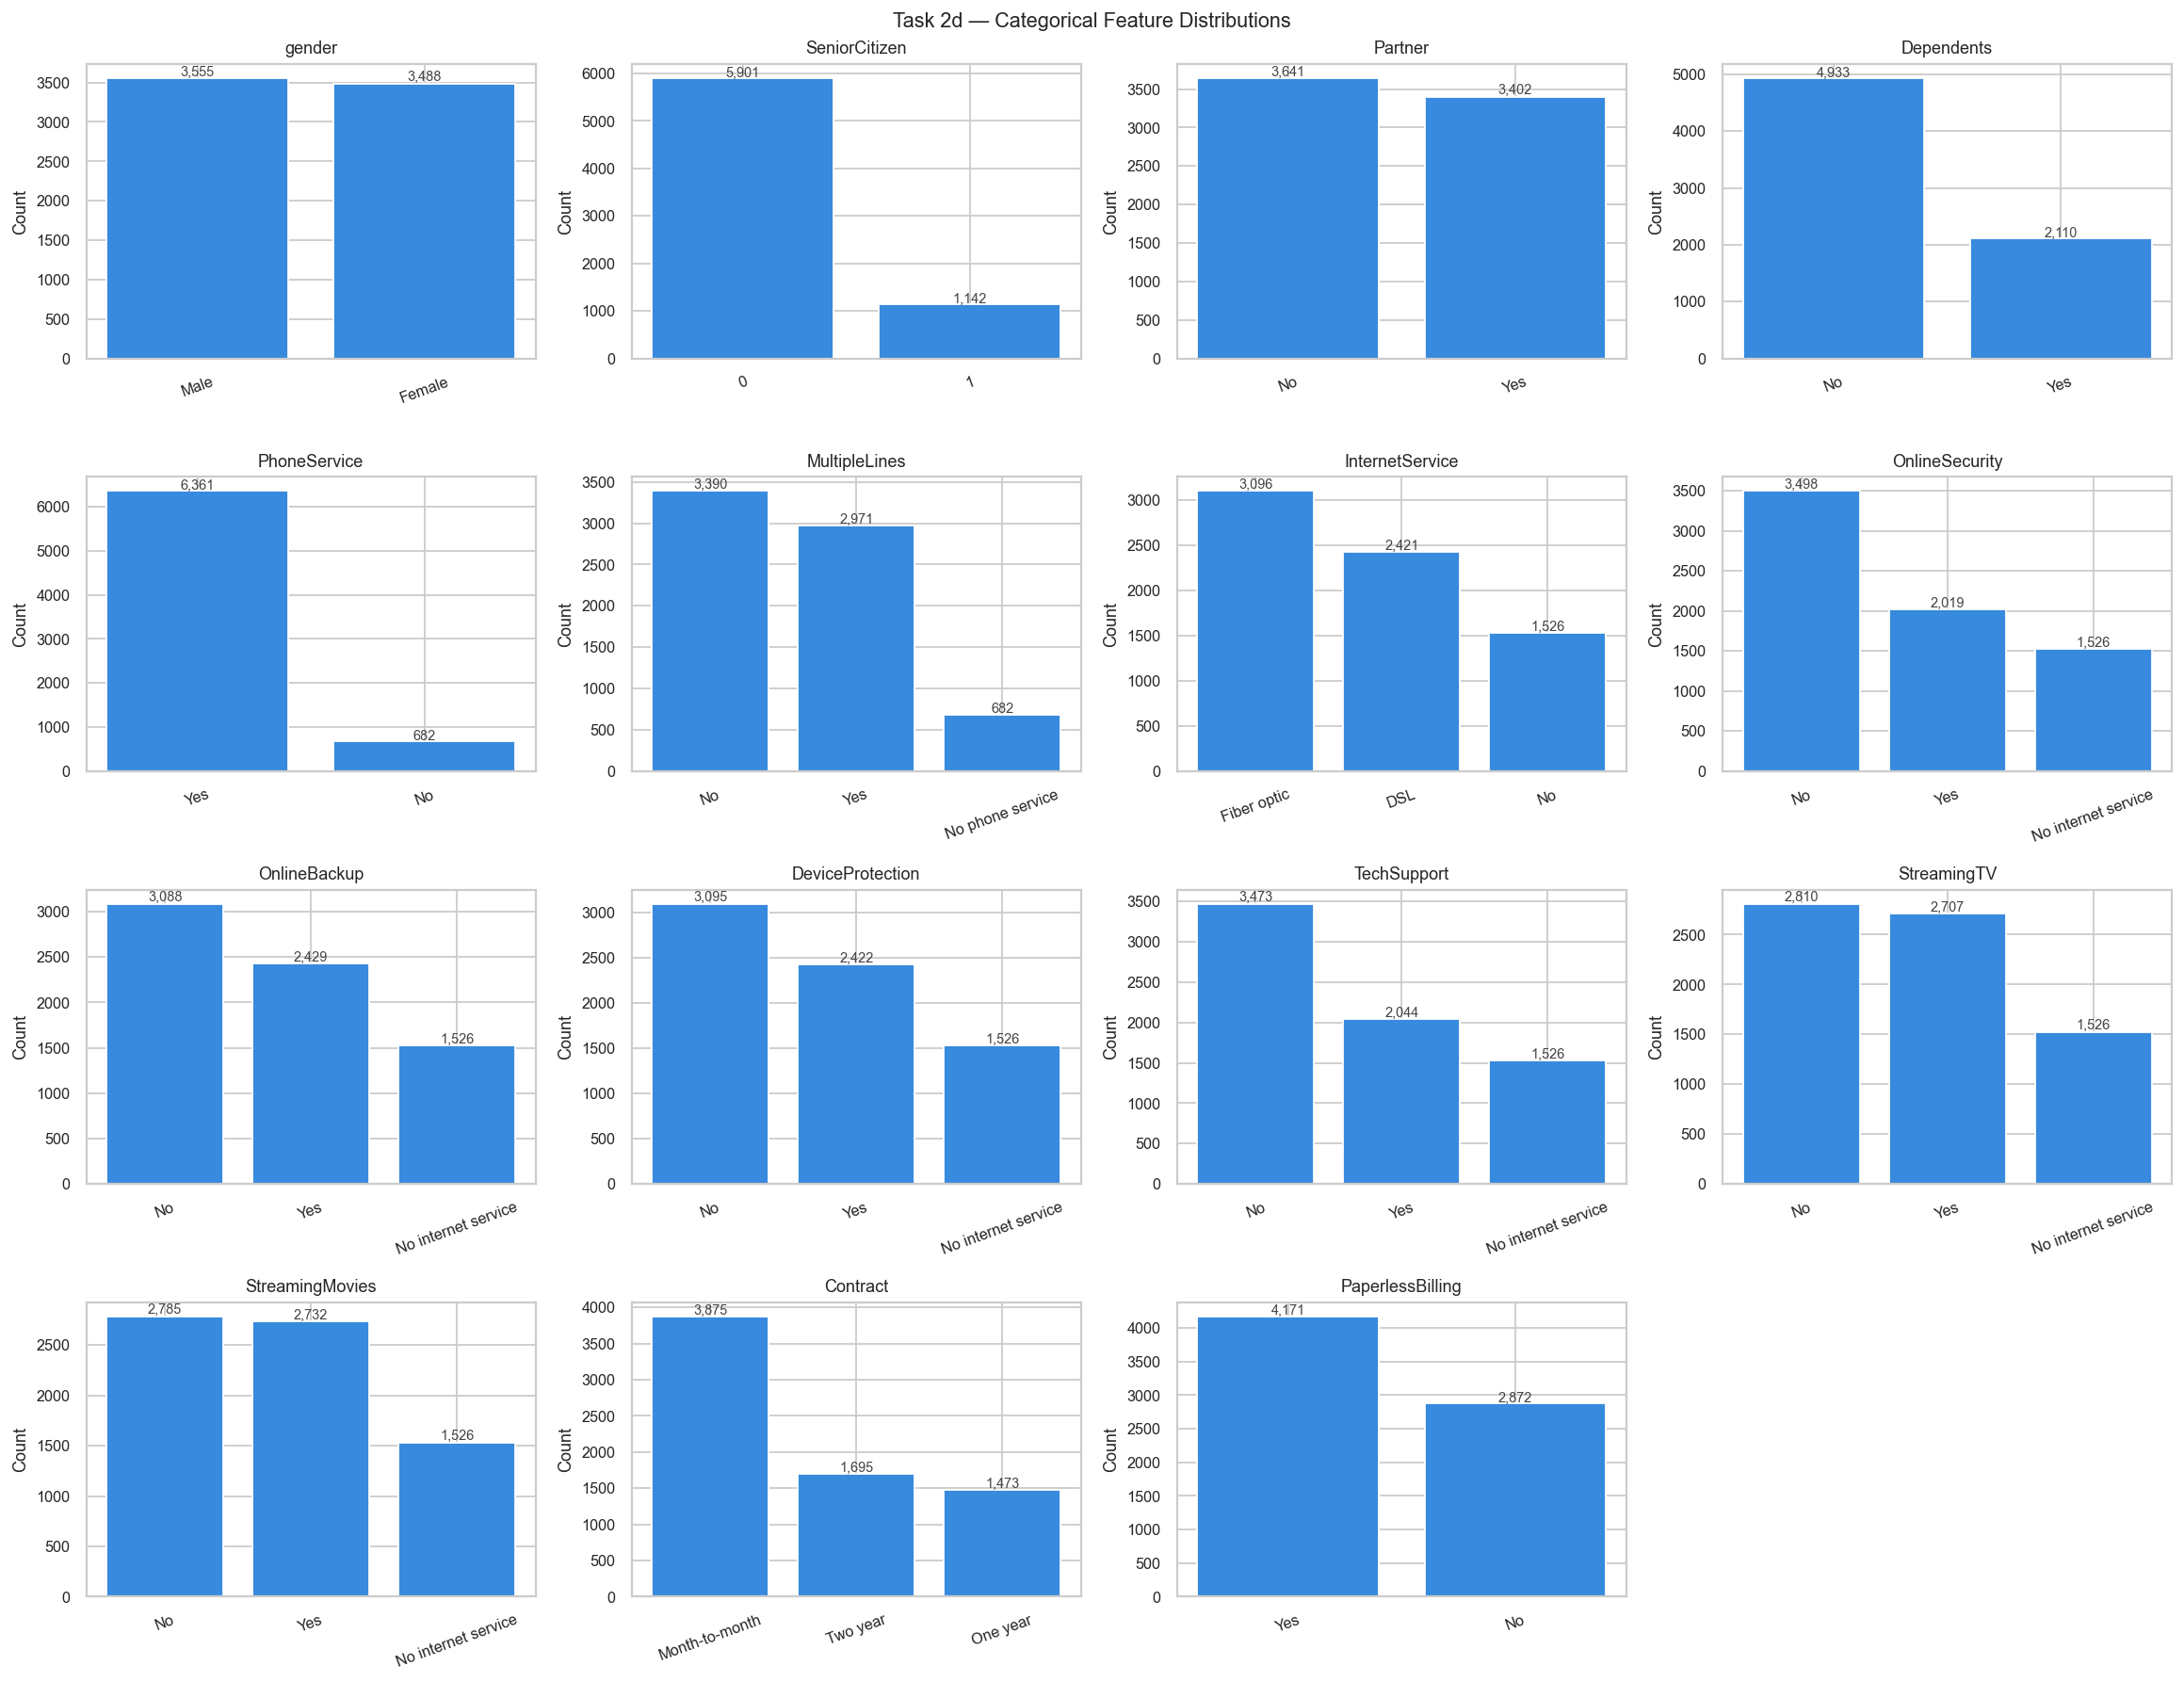


  Chart saved: day3_univariate_categorical.png

  Task 2 complete ✓


In [7]:
# =============================================================================
# TASK 2 — UNIVARIATE ANALYSIS
# =============================================================================
print("\n[TASK 2] Univariate analysis...")

# ── 2a. Numerical distributions ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Task 2a — Numerical Feature Distributions", fontsize=12, y=1.01)

for ax, col in zip(axes, NUM_COLS):
    data = df[col]
    ax.hist(data, bins=40, color=CLR_NEUT, edgecolor="white", linewidth=0.4)
    ax.axvline(data.mean(),   color="#E24B4A", lw=1.4, ls="--", label=f"Mean: {data.mean():.1f}")
    ax.axvline(data.median(), color="#F4A83A", lw=1.4, ls=":",  label=f"Median: {data.median():.1f}")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.legend(loc="upper right")

plt.tight_layout()
plt.savefig("../visuals/day3_univariate_numerical.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved: day3_univariate_numerical.png")

# ── 2b. Numerical descriptive stats ──────────────────────────────────────────
print("\n" + "=" * 60)
print("  NUMERICAL COLUMN STATISTICS")
print("=" * 60)
desc = df[NUM_COLS].describe().T
desc["skew"]     = df[NUM_COLS].skew().round(3)
desc["kurtosis"] = df[NUM_COLS].kurtosis().round(3)
print(desc.to_string())
print("""
  Interpretation:
  • tenure       — Bimodal: spikes at 0-2 months (new) and ~70 months (loyal)
  • MonthlyCharges — Right-leaning; premium tier customers visible ~$80-100
  • TotalCharges  — Right-skewed (expected: high tenure = high total spend)
""")

# ── 2c. Categorical value counts ─────────────────────────────────────────────
print("=" * 60)
print("  CATEGORICAL COLUMN VALUE COUNTS")
print("=" * 60)
for col in CAT_COLS:
    vc = df[col].value_counts()
    print(f"\n  {col}:")
    for val, cnt in vc.items():
        pct = cnt / len(df) * 100
        print(f"    {str(val):<30} {cnt:>5,}  ({pct:.1f}%)")

# ── 2d. Categorical bar overview chart ───────────────────────────────────────
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
fig.suptitle("Task 2d — Categorical Feature Distributions", fontsize=12)
axes = axes.flatten()

for i, col in enumerate(CAT_COLS):
    vc = df[col].value_counts()
    axes[i].bar(vc.index.astype(str), vc.values, color=CLR_NEUT, edgecolor="white")
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=20)
    for j, v in enumerate(vc.values):
        axes[i].text(j, v + 30, f"{v:,}", ha="center", fontsize=8, color="#444")

# Hide unused subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig("C:/Users/white/Downloads/Learn/Churn_project/visuals/day3_univariate_categorical.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  Chart saved: day3_univariate_categorical.png")
print("\n  Task 2 complete ✓")


[TASK 3] Bivariate analysis — features vs Churn...


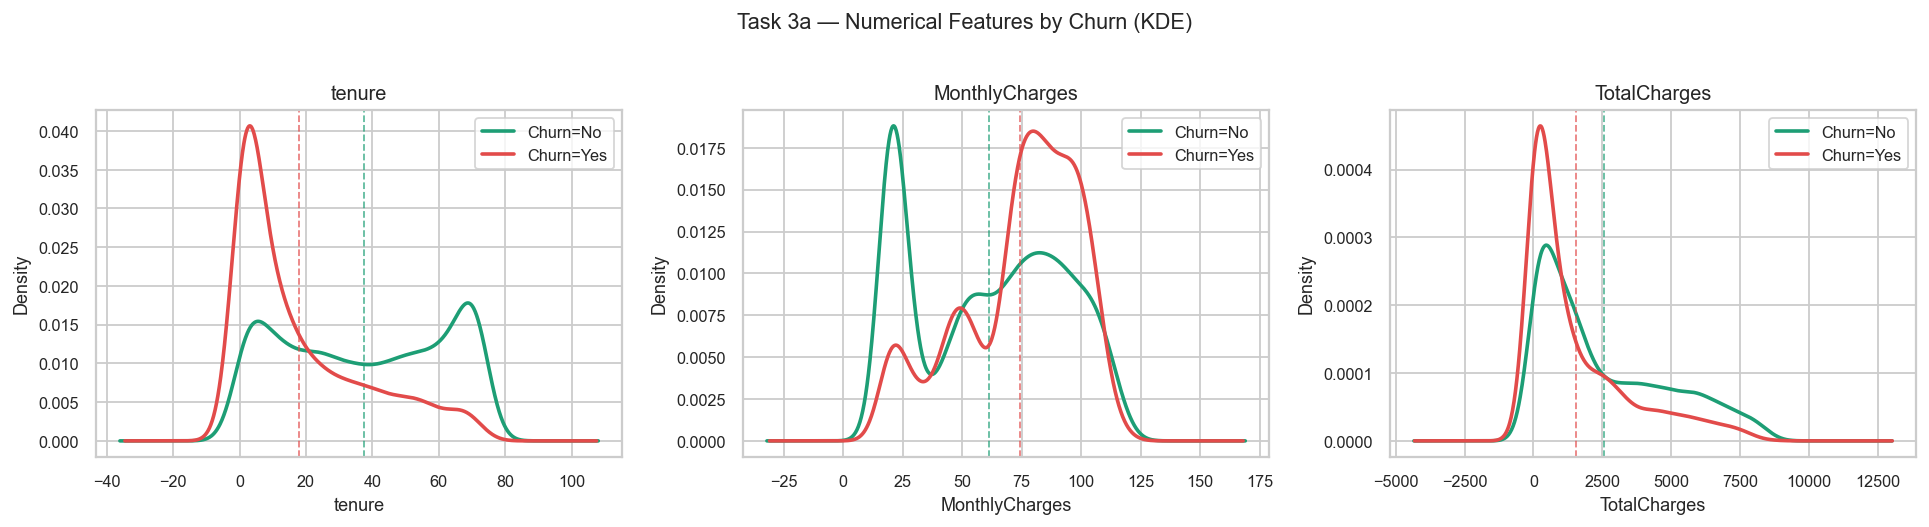

  Chart saved: day3_bivariate_numerical_kde.png


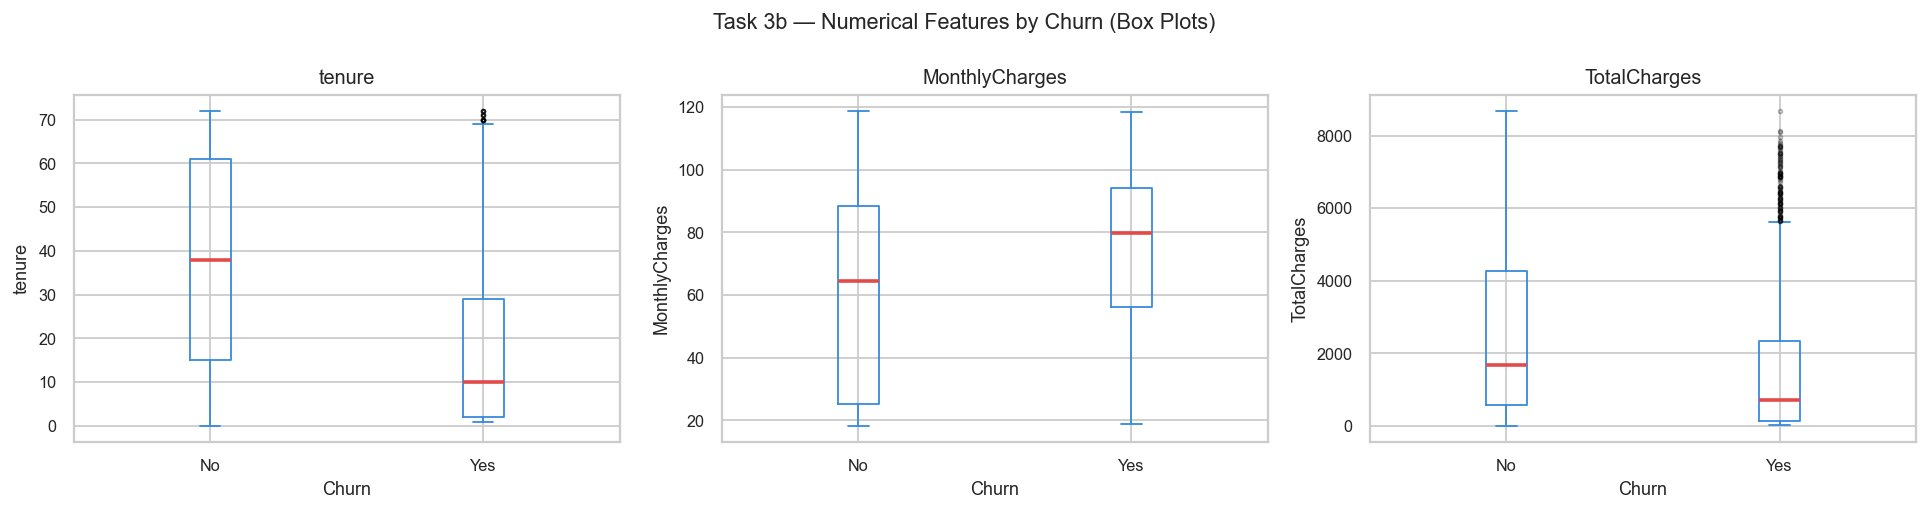

  Chart saved: day3_bivariate_numerical_box.png

  MEAN VALUES BY CHURN GROUP
       tenure  MonthlyCharges  TotalCharges
Churn                                      
No      37.57           61.27       2549.91
Yes     17.98           74.44       1531.80

  Interpretation:
  • tenure        — Churned customers average ~18 months vs ~38 for retained
  • MonthlyCharges — Churned customers pay ~$74/mo vs ~$61 retained (premium plans → dissatisfaction?)
  • TotalCharges  — Churned customers have lower total spend due to short tenure

  CHURN RATE BY CATEGORICAL FEATURE

  gender:
    Female                          26.9%  █████████████
    Male                            26.2%  █████████████

  SeniorCitizen:
    0                               23.6%  ███████████
    1                               41.7%  ████████████████████

  Partner:
    No                              33.0%  ████████████████
    Yes                             19.7%  █████████

  Dependents:
    No                     

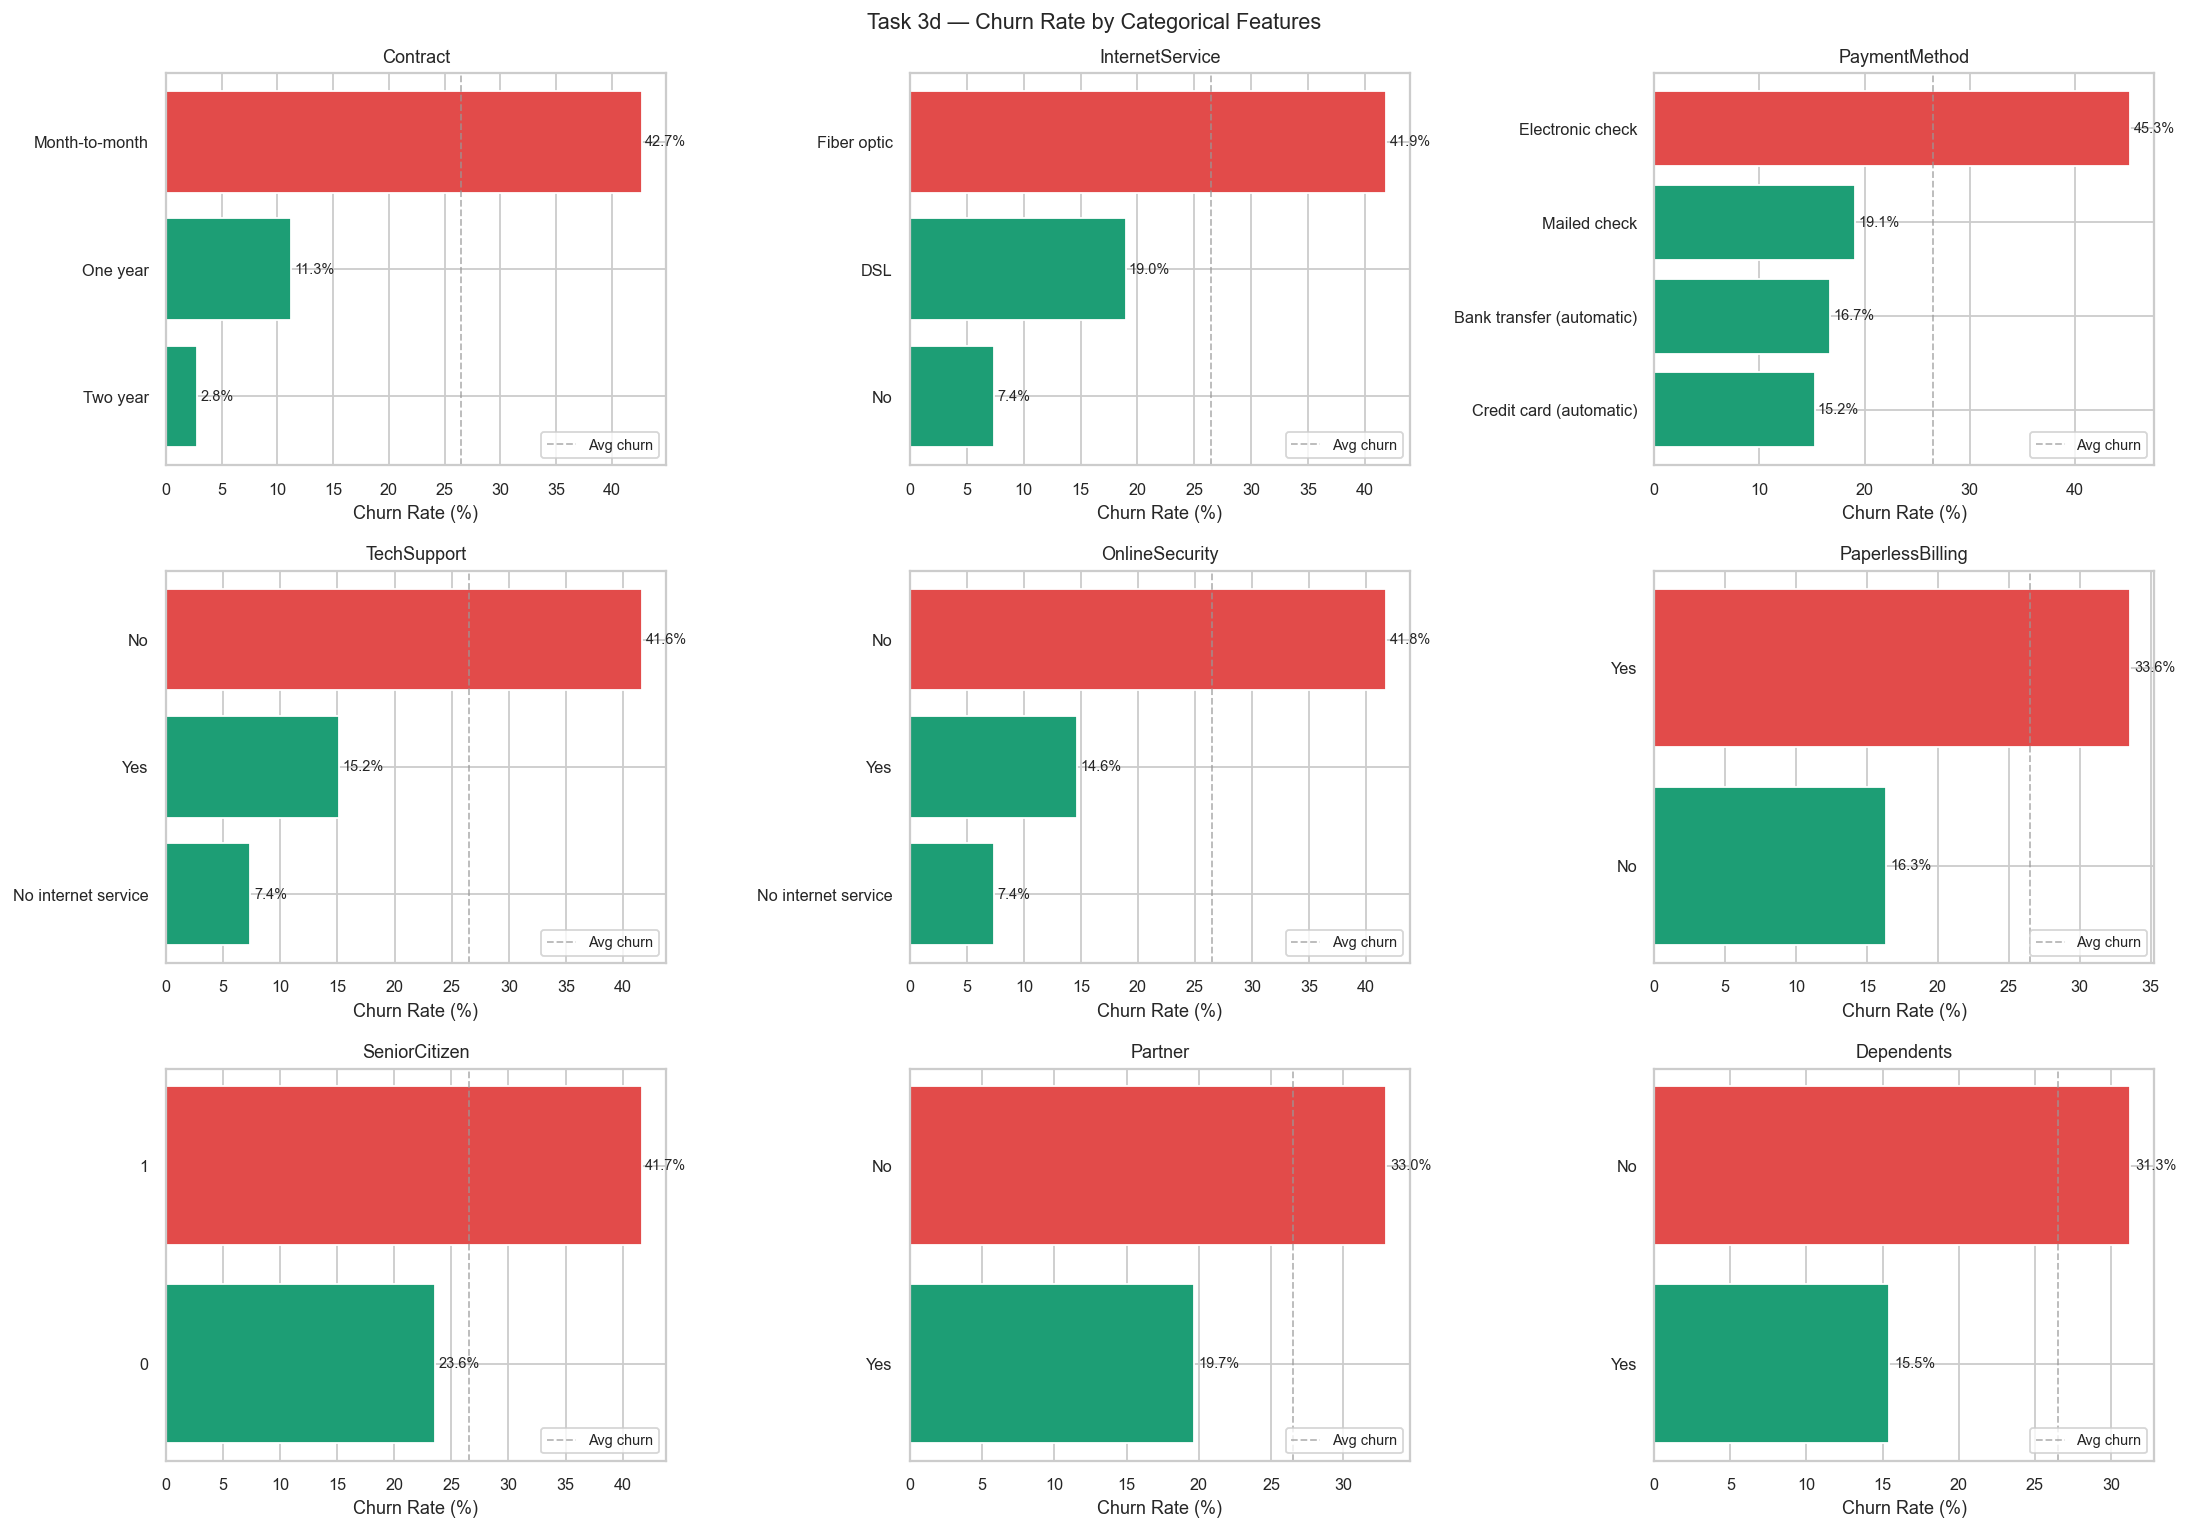


  Chart saved: day3_bivariate_categorical.png

  TENURE SEGMENTS — CHURN RATE
                customers  churn_rate
tenure_segment                       
0-6m                 1470       53.33
7-12m                 705       35.89
13-24m               1024       28.71
25-36m                832       21.63
37-48m                762       19.03
49-60m                832       14.42
61-72m               1407        6.61


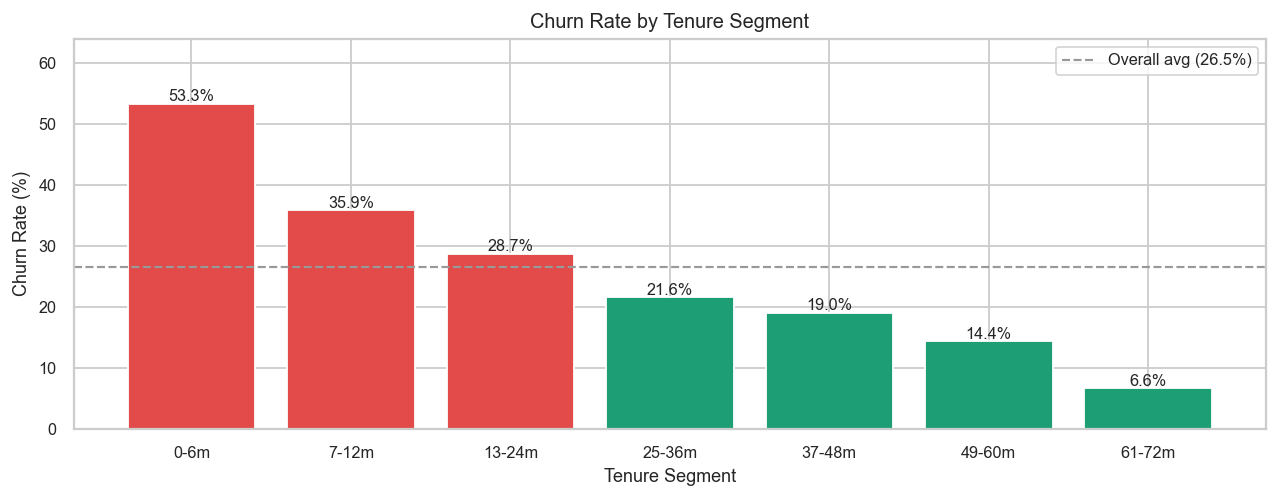

  Chart saved: day3_tenure_segments.png

  Interpretation:
  • First 6 months : HIGHEST churn risk (onboarding friction / unmet expectations)
  • 12-24 months   : Churn stabilises — customers who stay past year 1 tend to commit
  • 60+ months     : Near-zero churn — long-tenured customers are very loyal



In [8]:
# =============================================================================
# TASK 3 — BIVARIATE ANALYSIS (Features vs Churn)
# =============================================================================
print("\n[TASK 3] Bivariate analysis — features vs Churn...")

# ── 3a. Numerical features — KDE by churn ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Task 3a — Numerical Features by Churn (KDE)", fontsize=12, y=1.01)

for ax, col in zip(axes, NUM_COLS):
    for label, color in [("No", CLR_RETAIN), ("Yes", CLR_CHURN)]:
        subset = df[df["Churn"] == label][col]
        subset.plot.kde(ax=ax, color=color, linewidth=2, label=f"Churn={label}")
        ax.axvline(subset.mean(), color=color, lw=1, ls="--", alpha=0.7)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.savefig("C:/Users/white/Downloads/Learn/Churn_project/visuals/day3_bivariate_numerical_kde.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved: day3_bivariate_numerical_kde.png")

# ── 3b. Numerical features — Box plots by churn ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Task 3b — Numerical Features by Churn (Box Plots)", fontsize=12, y=1.01)

for ax, col in zip(axes, NUM_COLS):
    df.boxplot(column=col, by="Churn", ax=ax,
               boxprops=dict(color=CLR_NEUT),
               medianprops=dict(color=CLR_CHURN, linewidth=2),
               whiskerprops=dict(color=CLR_NEUT),
               capprops=dict(color=CLR_NEUT),
               flierprops=dict(marker="o", markersize=2, alpha=0.3, color=CLR_NEUT))
    ax.set_title(col)
    ax.set_xlabel("Churn")
    ax.set_ylabel(col)

plt.suptitle("")  # Remove auto-generated suptitle from boxplot
fig.suptitle("Task 3b — Numerical Features by Churn (Box Plots)", fontsize=12)
plt.tight_layout()
plt.savefig("C:/Users/white/Downloads/Learn/Churn_project/visuals/day3_bivariate_numerical_box.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved: day3_bivariate_numerical_box.png")

# ── 3b stats: Mean by churn group ────────────────────────────────────────────
print("\n" + "=" * 60)
print("  MEAN VALUES BY CHURN GROUP")
print("=" * 60)
mean_by_churn = df.groupby("Churn")[NUM_COLS].mean().round(2)
print(mean_by_churn.to_string())
print("""
  Interpretation:
  • tenure        — Churned customers average ~18 months vs ~38 for retained
  • MonthlyCharges — Churned customers pay ~$74/mo vs ~$61 retained (premium plans → dissatisfaction?)
  • TotalCharges  — Churned customers have lower total spend due to short tenure
""")

# ── 3c. Categorical features — Churn rate per category ───────────────────────
print("=" * 60)
print("  CHURN RATE BY CATEGORICAL FEATURE")
print("=" * 60)

churn_rates = {}
for col in CAT_COLS:
    rate = df.groupby(col)["Churn_bin"].mean().mul(100).round(2)
    churn_rates[col] = rate
    print(f"\n  {col}:")
    for val, pct in rate.items():
        bar = "█" * int(pct / 2)
        print(f"    {str(val):<30} {pct:>5.1f}%  {bar}")

# ── 3d. Categorical bivariate chart (high-impact features) ───────────────────
HIGH_IMPACT = ["Contract", "InternetService", "PaymentMethod",
               "TechSupport", "OnlineSecurity", "PaperlessBilling",
               "SeniorCitizen", "Partner", "Dependents"]

fig, axes = plt.subplots(3, 3, figsize=(17, 12))
fig.suptitle("Task 3d — Churn Rate by Categorical Features", fontsize=12)
axes = axes.flatten()

for i, col in enumerate(HIGH_IMPACT):
    grouped = df.groupby(col)["Churn_bin"].mean().mul(100).sort_values()
    bars = axes[i].barh(grouped.index.astype(str), grouped.values,
                        color=[CLR_CHURN if v > 26.5 else CLR_RETAIN for v in grouped.values],
                        edgecolor="white")
    axes[i].axvline(26.5, color="#999", lw=1, ls="--", alpha=0.7, label="Avg churn")
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("Churn Rate (%)")
    for bar_obj, val in zip(bars, grouped.values):
        axes[i].text(val + 0.3, bar_obj.get_y() + bar_obj.get_height()/2,
                     f"{val:.1f}%", va="center", fontsize=8)
    axes[i].legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.savefig("C:/Users/white/Downloads/Learn/Churn_project/visuals/day3_bivariate_categorical.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  Chart saved: day3_bivariate_categorical.png")

# ── 3e. Tenure segments — churn rate analysis ────────────────────────────────
print("\n" + "=" * 60)
print("  TENURE SEGMENTS — CHURN RATE")
print("=" * 60)

bins   = [0, 6, 12, 24, 36, 48, 60, 72]
labels = ["0-6m", "7-12m", "13-24m", "25-36m", "37-48m", "49-60m", "61-72m"]
df["tenure_segment"] = pd.cut(df["tenure"], bins=bins, labels=labels, right=True)

seg_stats = df.groupby("tenure_segment", observed=True).agg(
    customers  = ("Churn_bin", "count"),
    churn_rate = ("Churn_bin", lambda x: x.mean() * 100)
).round(2)
print(seg_stats.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
colors = [CLR_CHURN if r > 26.5 else CLR_RETAIN for r in seg_stats["churn_rate"]]
ax.bar(seg_stats.index.astype(str), seg_stats["churn_rate"], color=colors, edgecolor="white")
ax.axhline(26.5, color="#999", lw=1.2, ls="--", label="Overall avg (26.5%)")
for j, (idx, row) in enumerate(seg_stats.iterrows()):
    ax.text(j, row["churn_rate"] + 0.4, f"{row['churn_rate']:.1f}%", ha="center", fontsize=9)
ax.set_title("Churn Rate by Tenure Segment", fontsize=11)
ax.set_xlabel("Tenure Segment")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, max(seg_stats["churn_rate"]) * 1.2)
ax.legend()
plt.tight_layout()
plt.savefig("C:/Users/white/Downloads/Learn/Churn_project/visuals/day3_tenure_segments.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved: day3_tenure_segments.png")
print("""
  Interpretation:
  • First 6 months : HIGHEST churn risk (onboarding friction / unmet expectations)
  • 12-24 months   : Churn stabilises — customers who stay past year 1 tend to commit
  • 60+ months     : Near-zero churn — long-tenured customers are very loyal
""")


[TASK 4] Correlation analysis...


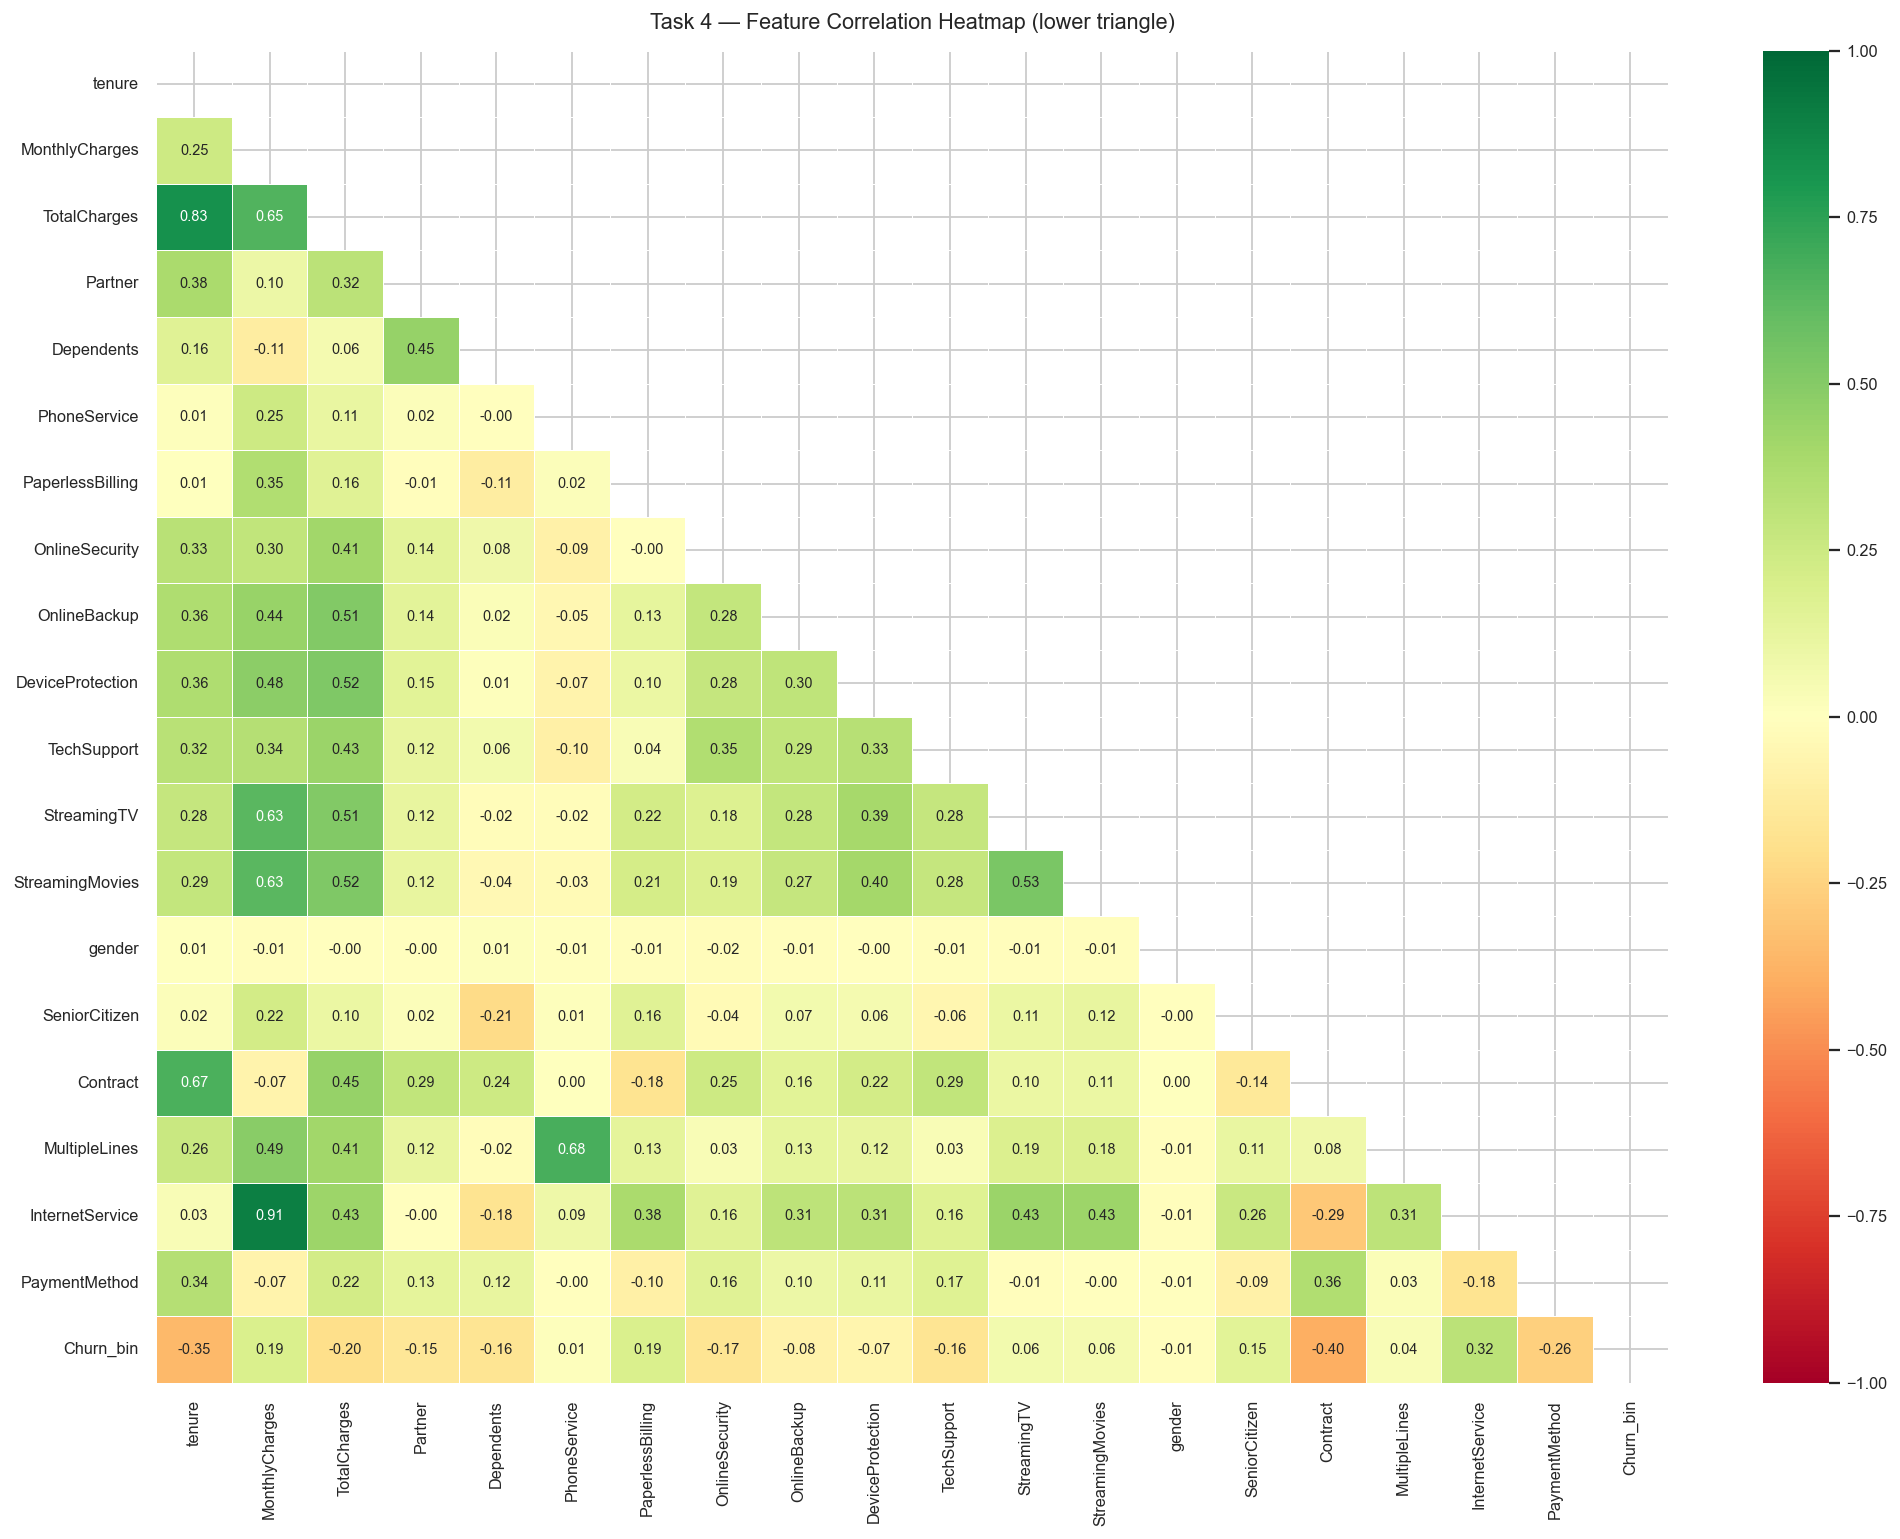

  Chart saved: day3_correlation_heatmap.png

  TOP FEATURE CORRELATIONS WITH CHURN
  Contract               r=-0.397  -------  ↓ lower  = more churn
  tenure                 r=-0.352  -------  ↓ lower  = more churn
  InternetService        r=+0.317  ++++++  ↑ higher = more churn
  PaymentMethod          r=-0.263  -----  ↓ lower  = more churn
  TotalCharges           r=-0.198  ---  ↓ lower  = more churn
  MonthlyCharges         r=+0.193  +++  ↑ higher = more churn
  PaperlessBilling       r=+0.192  +++  ↑ higher = more churn
  OnlineSecurity         r=-0.171  ---  ↓ lower  = more churn
  TechSupport            r=-0.165  ---  ↓ lower  = more churn
  Dependents             r=-0.164  ---  ↓ lower  = more churn
  SeniorCitizen          r=+0.151  +++  ↑ higher = more churn
  Partner                r=-0.150  ---  ↓ lower  = more churn
  OnlineBackup           r=-0.082  -  ↓ lower  = more churn
  DeviceProtection       r=-0.066  -  ↓ lower  = more churn
  StreamingTV            r=+0.063  +  ↑ 

In [8]:
# =============================================================================
# TASK 4 — CORRELATION HEATMAP & MULTICOLLINEARITY CHECK
# =============================================================================
print("\n[TASK 4] Correlation analysis...")

# ── 4a. Encode all columns numerically for correlation ───────────────────────
df_enc = df.copy()

# Binary Yes/No columns
binary_cols = [
    "Partner", "Dependents", "PhoneService", "PaperlessBilling",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]
for col in binary_cols:
    df_enc[col] = df_enc[col].map({"Yes": 1, "No": 0, "No phone service": 0, "No internet service": 0})

df_enc["gender"]       = df_enc["gender"].map({"Male": 1, "Female": 0})
df_enc["Contract"]     = df_enc["Contract"].map({"Month-to-month": 0, "One year": 1, "Two year": 2})
df_enc["MultipleLines"]= df_enc["MultipleLines"].map({"Yes": 2, "No": 1, "No phone service": 0})
df_enc["InternetService"] = df_enc["InternetService"].map({"Fiber optic": 2, "DSL": 1, "No": 0})
df_enc["PaymentMethod"]   = df_enc["PaymentMethod"].map({
    "Electronic check": 0, "Mailed check": 1,
    "Bank transfer (automatic)": 2, "Credit card (automatic)": 3
})

CORR_COLS = NUM_COLS + binary_cols + [
    "gender", "SeniorCitizen", "Contract", "MultipleLines",
    "InternetService", "PaymentMethod", "Churn_bin"
]

corr_matrix = df_enc[CORR_COLS].corr()

# ── 4b. Correlation heatmap ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Show lower triangle only
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f", linewidths=0.4,
    cmap="RdYlGn", center=0, vmin=-1, vmax=1,
    annot_kws={"size": 8}, ax=ax
)
ax.set_title("Task 4 — Feature Correlation Heatmap (lower triangle)", fontsize=12, pad=12)
plt.tight_layout()
plt.savefig("C:/Users/white/Downloads/Learn/Churn_project/visuals/day3_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved: day3_correlation_heatmap.png")

# ── 4c. Top correlations with Churn ──────────────────────────────────────────
print("\n" + "=" * 60)
print("  TOP FEATURE CORRELATIONS WITH CHURN")
print("=" * 60)
churn_corr = (
    corr_matrix["Churn_bin"]
    .drop("Churn_bin")
    .sort_values(key=abs, ascending=False)
)
for feat, val in churn_corr.items():
    direction = "↑ higher = more churn" if val > 0 else "↓ lower  = more churn"
    bar = ("+" if val > 0 else "-") * int(abs(val) * 20)
    print(f"  {feat:<22} r={val:>+.3f}  {bar}  {direction}")

# ── 4d. Multicollinearity flag ────────────────────────────────────────────────
print("\n" + "=" * 60)
print("  MULTICOLLINEARITY CHECK (|r| > 0.7 between features)")
print("=" * 60)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], round(r, 3)))

if high_corr_pairs:
    for c1, c2, r in high_corr_pairs:
        print(f"  ⚠  {c1} ↔ {c2}  →  r = {r}")
    print("""
  Action: TotalCharges is a product of tenure × MonthlyCharges — consider
  dropping it or using VIF in Day 8 to confirm multicollinearity handling.
""")
else:
    print("  No severe multicollinearity detected (|r| ≤ 0.7 for all pairs).")

print("  Task 4 complete ✓")

In [10]:
# =============================================================================
# TASK 5 — EDA FINDINGS SUMMARY
# =============================================================================
print("\n" + "=" * 60)
print("  TASK 5 — EDA KEY FINDINGS")
print("=" * 60)

overall_churn = df["Churn_bin"].mean() * 100

findings = [
    ("Overall churn rate",          f"{overall_churn:.1f}%"),
    ("Highest-risk contract type",  "Month-to-month (~43% churn)"),
    ("Lowest-risk contract type",   "Two year (~3% churn)"),
    ("Highest-risk internet type",  "Fiber optic (~42% churn)"),
    ("Highest-risk tenure band",    "0-6 months (new customers)"),
    ("Lowest-risk tenure band",     "61-72 months (<5% churn)"),
    ("Top correlated feature (+)",  "Month-to-month contract"),
    ("Top correlated feature (-)",  "Contract length (longer = safer)"),
    ("Multicollinearity warning",   "TotalCharges ↔ tenure & MonthlyCharges"),
    ("Senior citizen churn rate",   f"{df[df['SeniorCitizen']==1]['Churn_bin'].mean()*100:.1f}% vs {df[df['SeniorCitizen']==0]['Churn_bin'].mean()*100:.1f}% non-senior"),
    ("No-add-on services risk",     "Customers with no security/support → ~40% churn"),
]

for finding, value in findings:
    print(f"  {'•'} {finding:<38} : {value}")

print(f"""
  PRIORITY FEATURES FOR MODELLING (Day 8):
  ─────────────────────────────────────────
  1. Contract          — Strongest single predictor
  2. tenure            — Clear separation between churn / retained
  3. InternetService   — Fiber optic customers at high risk
  4. MonthlyCharges    — Higher bills correlate with churn
  5. OnlineSecurity    — Lack of add-on = vulnerability signal
  6. TechSupport       — Same pattern as OnlineSecurity
  7. PaymentMethod     — Electronic check users churn most
  8. SeniorCitizen     — Demographic risk factor

  NOTE: TotalCharges shows multicollinearity with tenure and MonthlyCharges.
  Use VIF analysis in Day 8 before including it in the model.
""")

print("=" * 60)
print("  TOMORROW — Day 4: DATA PREPROCESSING")
print("  -> Fix TotalCharges (done today — formalise the pipeline)")
print("  -> Encode categorical variables (Label + One-Hot)")
print("  -> Handle outliers in MonthlyCharges / TotalCharges")
print("  -> Feature scaling (StandardScaler / MinMaxScaler)")
print("  -> Train/test split (stratified on Churn)")
print("=" * 60)
print("\n  Day 3 Complete ✓  —  5 charts saved to /visuals/")


  TASK 5 — EDA KEY FINDINGS
  • Overall churn rate                     : 26.5%
  • Highest-risk contract type             : Month-to-month (~43% churn)
  • Lowest-risk contract type              : Two year (~3% churn)
  • Highest-risk internet type             : Fiber optic (~42% churn)
  • Highest-risk tenure band               : 0-6 months (new customers)
  • Lowest-risk tenure band                : 61-72 months (<5% churn)
  • Top correlated feature (+)             : Month-to-month contract
  • Top correlated feature (-)             : Contract length (longer = safer)
  • Multicollinearity warning              : TotalCharges ↔ tenure & MonthlyCharges
  • Senior citizen churn rate              : 41.7% vs 23.6% non-senior
  • No-add-on services risk                : Customers with no security/support → ~40% churn

  PRIORITY FEATURES FOR MODELLING (Day 8):
  ─────────────────────────────────────────
  1. Contract          — Strongest single predictor
  2. tenure            — Clear sep